# EMD + LMS-Based Schizophrenia Classification on Dataset 1 using Alpha-Band Connectivity Features

This notebook implements a combined EMD + LMS EEG classification pipeline on Dataset 1 using phase-based connectivity features.

Each EEG recording is segmented into 5-second windows, decomposed into Intrinsic Mode Functions (IMFs) using Empirical Mode Decomposition, filtered with an LMS procedure, and transformed into connectivity descriptors based on PLV and PLI.

Only IMFs associated with the alpha band are retained before feature extraction.

In [ ]:
import mne
from glob import glob
import numpy as np
from PyEMD import EMD
from scipy.signal import hilbert, lfilter, welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVC
from scipy.signal import butter, filtfilt

In [ ]:
def load_eeg(file_path):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    return raw.get_data()
healthy_file_paths = sorted(glob(f"dataverse_files/h*.edf"))
schizo_file_paths = sorted(glob(f"dataverse_files/s*.edf"))
healthy_signals = [load_eeg(file) for file in healthy_file_paths]
schizo_signals = [load_eeg(file) for file in schizo_file_paths]

Extracting EDF parameters from /content/dataverse_files/h01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
Extracting EDF parameters from /content/dataverse_files/h02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 227499  =      0.000 ...   909.996 secs...
Extracting EDF parameters from /content/dataverse_files/h03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 227499  =      0.000 ...   909.996 secs...
Extracting EDF parameters from /content/dataverse_files/h04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
Extracting EDF parameters from /content/dataverse_files/h05.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 236249  

In [ ]:
def segment_signal(signal, segment_duration, fs):
    segment_length = int(segment_duration * fs)
    return [signal[:, i:i + segment_length] for i in range(0, signal.shape[1], segment_length)]

fs = 250
segment_duration = 5
healthy_segments = [segment_signal(sig, segment_duration, fs) for sig in healthy_signals]
schizo_segments = [segment_signal(sig, segment_duration, fs) for sig in schizo_signals]
healthy_segments = [seg for subj in healthy_segments for seg in subj]
schizo_segments = [seg for subj in schizo_segments for seg in subj]

In [ ]:
def apply_emd(signal, fs, max_imf=3, alpha_range=(8, 13)):
    imfs_all_channels = []
    for ch in range(signal.shape[0]):
        emd = EMD()
        imfs = emd(signal[ch, :])
        imfs_all_channels.append(imfs)

    max_imf_per_channel = max([imfs.shape[0] for imfs in imfs_all_channels])
    imfs_array = np.zeros((signal.shape[0], max_imf_per_channel, signal.shape[1]))
    for i, imfs in enumerate(imfs_all_channels):
        imfs_array[i, :imfs.shape[0], :] = imfs

    return select_alpha_imfs(imfs_array, fs, max_imf, alpha_range)

In [ ]:
def select_alpha_imfs(imfs_array, fs, max_imf=3, alpha_range=(8, 13)):
    n_channels, n_imf, n_times = imfs_array.shape
    selected_imfs = np.zeros((n_channels, max_imf, n_times))

    for ch in range(n_channels):
        channel_imfs = imfs_array[ch, :, :]
        for i_imf in range(min(n_imf, max_imf)):
            freq_dom = dominant_frequency(channel_imfs[i_imf, :], fs)
            if alpha_range[0] <= freq_dom <= alpha_range[1]:
                selected_imfs[ch, i_imf, :] = channel_imfs[i_imf, :]
    return selected_imfs

In [ ]:
def dominant_frequency(imf_signal, fs):
    f, Pxx = welch(imf_signal, fs=fs, nperseg=fs)
    return f[np.argmax(Pxx)]


def lms_filter(signal, reference, mu=0.01, n_iter=1000):
    n = len(signal)
    y = np.zeros(n)
    e = np.zeros(n)
    w = np.zeros(n_iter)

    for i in range(n):
        y[i] = np.dot(w[:min(i, n_iter)], reference[:min(i, n_iter)][::-1])
        e[i] = signal[i] - y[i]
        w[:min(i, n_iter)] += 2 * mu * e[i] * reference[:min(i, n_iter)][::-1]
    return e

def apply_lms_on_imfs(imfs, mu=0.01):
    n_channels, n_imf, n_times = imfs.shape
    filtered_imfs = np.zeros_like(imfs)
    for ch in range(n_channels):
        for imf_idx in range(n_imf):
            filtered_imfs[ch, imf_idx, :] = lms_filter(imfs[ch, imf_idx, :], imfs[ch, imf_idx, :], mu=mu)
    return filtered_imfs

In [ ]:
def compute_phase_matrix(imfs_array):
    if imfs_array.size == 0:
        return np.empty((0, 0, 0))
    analytic_signal = hilbert(imfs_array, axis=2)
    phases = np.angle(analytic_signal)
    return phases

def compute_plv(phases):
    n_channels, n_imf, n_times = phases.shape
    plv_matrix = np.zeros((n_channels, n_channels, n_imf))
    for imf_idx in range(n_imf):
        for ch1 in range(n_channels):
            for ch2 in range(n_channels):
                phase_diff = phases[ch1, imf_idx, :] - phases[ch2, imf_idx, :]
                plv_matrix[ch1, ch2, imf_idx] = np.abs(np.mean(np.exp(1j * phase_diff)))
    return plv_matrix

def compute_pli(phases):
    n_channels, n_imf, n_times = phases.shape
    pli_matrix = np.zeros((n_channels, n_channels, n_imf))
    for imf_idx in range(n_imf):
        for ch1 in range(n_channels):
            for ch2 in range(n_channels):
                phase_diff = phases[ch1, imf_idx, :] - phases[ch2, imf_idx, :]
                pli_matrix[ch1, ch2, imf_idx] = np.abs(np.mean(np.sign(np.sin(phase_diff))))
    return pli_matrix


In [ ]:
def extract_features_from_phases(phases_array):
    plv_feat = compute_plv(phases_array).flatten()
    pli_feat = compute_pli(phases_array).flatten()
    features = np.concatenate([plv_feat, pli_feat])
    return features


In [ ]:
def build_dataset(phases_list, label):
    X = []
    y = []
    for p in phases_list:
        if p.size == 0:
            continue
        feat = extract_features_from_phases(p)
        X.append(feat)
        y.append(label)
    return X, y


In [ ]:
healthy_imfs = Parallel(n_jobs=-1)(delayed(apply_emd)(seg, fs) for seg in healthy_segments)
schizo_imfs = Parallel(n_jobs=-1)(delayed(apply_emd)(seg, fs) for seg in schizo_segments)
healthy_imfs = Parallel(n_jobs=-1)(delayed(apply_lms_on_imfs)(imf) for imf in healthy_imfs)
schizo_imfs = Parallel(n_jobs=-1)(delayed(apply_lms_on_imfs)(imf) for imf in schizo_imfs)
healthy_phases = Parallel(n_jobs=-1)(delayed(compute_phase_matrix)(imf) for imf in healthy_imfs)
schizo_phases = Parallel(n_jobs=-1)(delayed(compute_phase_matrix)(imf) for imf in schizo_imfs)

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76       530
           1       0.77      0.91      0.83       625

    accuracy                           0.80      1155
   macro avg       0.81      0.79      0.79      1155
weighted avg       0.81      0.80      0.80      1155



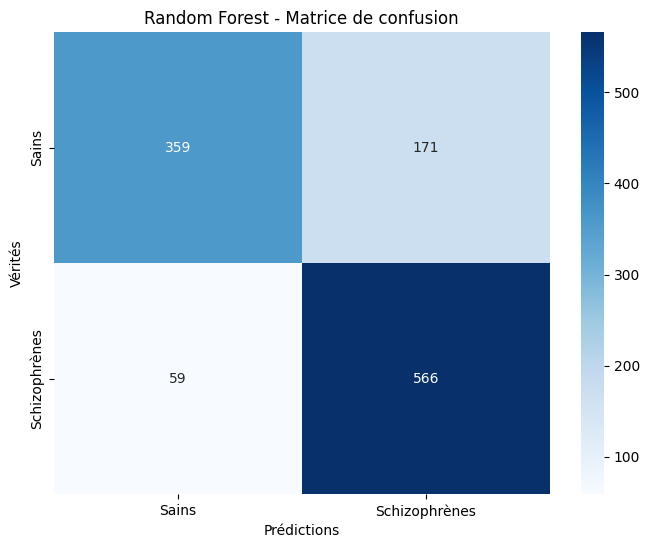

In [ ]:
X_healthy, y_healthy = build_dataset(healthy_phases, 0)
X_schizo, y_schizo = build_dataset(schizo_phases, 1)
X = np.array(X_healthy + X_schizo)
y = np.array(y_healthy + y_schizo)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


print("Classification Report:")
print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Sains", "Schizophrènes"], yticklabels=["Sains", "Schizophrènes"])
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Random Forest - Matrice de confusion")
plt.show()


In [ ]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.2f}")


Accuracy : 0.80
